Roll Number: CH.SC.U4CSE24123
Name: M A Kaushik
PRINCIPAL COMPONENT ANALYSIS 2

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {
    'Variable': ['Climate', 'Housing', 'Health', 'Crime', 'Transportation',
                 'Education', 'Arts', 'Recreation', 'Economy'],
    'Component1': [0.190, 0.544, 0.782, 0.365, 0.585, 0.394, 0.985, 0.520, 0.142],
    'Component2': [0.017, 0.020, -0.605, 0.294, 0.085, -0.273, 0.126, 0.402, 0.150],
    'Component3': [0.207, 0.204, 0.144, 0.585, 0.234, 0.027, -0.111, 0.519, 0.239]
}
df = pd.DataFrame(data)
df

,Variable,Component1,Component2,Component3
0,Climate,0.190,0.017,0.207
1,Housing,0.544,0.020,0.204
2,Health,0.782,-0.605,0.144
3,Crime,0.365,0.294,0.585
4,Transportation,0.585,0.085,0.234
5,Education,0.394,-0.273,0.027
6,Arts,0.985,0.126,-0.111
7,Recreation,0.520,0.402,0.519
8,Economy,0.142,0.150,0.239


In [ ]:
for comp in ['Component1', 'Component2', 'Component3']:
    df['abs_' + comp] = df[comp].abs()
    top_var = df.loc[df['abs_' + comp].idxmax(), 'Variable']
    top_val = df.loc[df['abs_' + comp].idxmax(), comp]
    print(f"{comp}: Highest loading variable = '{top_var}' (loading = {top_val})")

Component1: Highest loading variable = 'Arts' (loading = 0.985)
Component2: Highest loading variable = 'Health' (loading = -0.605)
Component3: Highest loading variable = 'Crime' (loading = 0.585)


In [ ]:
pc1_sorted = df[['Variable', 'Component1']].reindex(
    df['Component1'].abs().sort_values(ascending=False).index
)
print("Variables ranked by loading on Principal Component (Component 1):")
print(pc1_sorted.to_string(index=False))
principal_variable = pc1_sorted.iloc[0]['Variable']
print(f"\nThe principal component is best represented by: '{principal_variable}'")

Variables ranked by loading on Principal Component (Component 1):
      Variable  Component1
          Arts       0.985
        Health       0.782
Transportation       0.585
       Housing       0.544
    Recreation       0.520
     Education       0.394
         Crime       0.365
       Climate       0.190
       Economy       0.142

The principal component is best represented by: 'Arts'


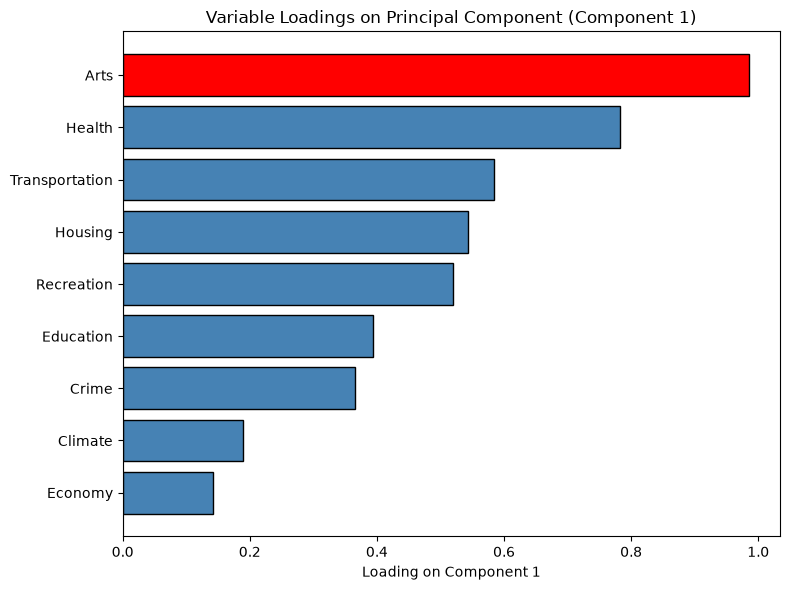

In [ ]:
import matplotlib.pyplot as plt
df_sorted = df.sort_values('abs_Component1', ascending=True)
plt.figure(figsize=(8, 6))
colors = ['red' if v == principal_variable else 'steelblue' for v in df_sorted['Variable']]
plt.barh(df_sorted['Variable'], df_sorted['Component1'], color=colors, edgecolor='k')
plt.xlabel('Loading on Component 1')
plt.title('Variable Loadings on Principal Component (Component 1)')
plt.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()